In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
def write_natural_member(var, scen, number, daily_ANT, scaling_factor):

    mem_ds = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_"+scen+"_m"+number+"_1951-2021.nc")
    mem_da = mem_ds[var]
    mem_da = mem_da.rename({'lon':'longitude','lat':'latitude'})
    
    nat_mem = mem_da - scaling_factor * daily_ANT
    
    nat_mem.to_netcdf('/nesi/nobackup/niwa00015/queenle/d4PDF/daily/naturalized/'+var+'_'+scen+'_m'+number+'_1951-2021.nc')

In [25]:
'''
NATURALIZE D4PDF-G TEMP AND RH
'''

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc')
NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_NAT_ensMean.nc')
ex_mem_da = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_m001_1951-2021.nc")['ta']
beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/d4pdf_beta_est_trunc_60_1951_2021.csv')
beta_est_df.set_index('type',inplace=True)

titles = {'ta':'temp','rha':'rel. humidity'}

#var = input('ta or rha: ')
var = 'ta'
print('naturalizing d4pdf ' + var)

ALL_da = ALL_ds[var]
NAT_da = NAT_ds[var]

ANT_da = ALL_da - NAT_da
daily_ANT = ANT_da.reindex_like(ex_mem_da, method="bfill")

scaling_factor = beta_est_df.loc['best_ant'][titles[var]]

for scen in ['HPB']:
    for ens_mem in range(1,101):
        
        print(ens_mem)

        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        write_natural_member(var, scen, number, daily_ANT, scaling_factor)

        break

naturalizing d4pdf ta
1


1


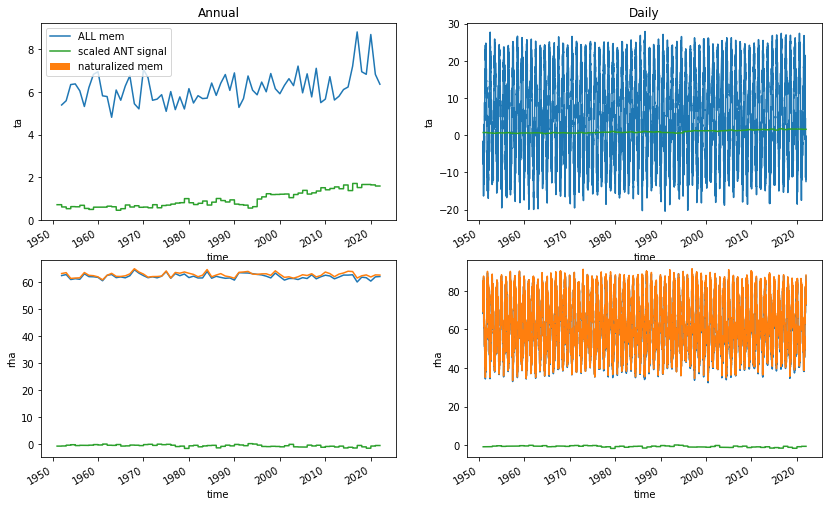

In [29]:
'''
PLOTTING NATURALIZED TA AND RH
'''

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc')
NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_NAT_ensMean.nc')
ex_mem_da = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_m001_1951-2021.nc")['ta']
beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/d4pdf_beta_est_trunc_60_1951_2021.csv')
beta_est_df.set_index('type',inplace=True)

titles = {'ta':'temp','rha':'rel. humidity'}

tasmax_ANT_da = ALL_ds['ta'] - NAT_ds['ta']
tasmax_daily_ANT = tasmax_ANT_da.reindex_like(ex_mem_da, method="bfill")
rh_ANT_da = ALL_ds['rha'] - NAT_ds['rha']
rh_daily_ANT = rh_ANT_da.reindex_like(ex_mem_da, method="bfill")
ANT_dict = {'ta':tasmax_daily_ANT,'rha':rh_daily_ANT}

scen='HPB'
for ens_mem in range(1,101):

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
    mem_ds = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_"+scen+"_m"+number+"_1951-2021.nc")
    #mem_ds = mem_ds.rename({'lon':'longitude','lat':'latitude'})
    fig,axs = plt.subplots(2,2,figsize=(14,8))
    for i,var in enumerate(['ta','rha']):
        scaling_factor = beta_est_df.loc['best_ant'][titles[var]]
        daily_ANT = ANT_dict[var]
        mem_da = mem_ds[var]
        nat_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/daily/naturalized/'+var+'_'+scen+'_m'+number+'_1951-2021.nc')

        mem_da.mean(['lat','lon']).resample(time='A').mean().plot(ax=axs[i][0],label='ALL mem')
        nat_mem.mean(['latitude','longitude']).resample(time='A').mean().plot(ax=axs[i][0],label='naturalized mem')
        (scaling_factor * daily_ANT).mean(['latitude','longitude']).plot(ax=axs[i][0],label='scaled ANT signal')
        
        mem_da.mean(['lat','lon']).plot(ax=axs[i][1],label='ALL mem')
        nat_mem.mean(['latitude','longitude']).plot(ax=axs[i][1],label='naturalized mem')
        (scaling_factor * daily_ANT).mean(['latitude','longitude']).plot(ax=axs[i][1],label='scaled ANT signal')

    axs[0][0].legend()
    axs[0][0].set_title('Annual')
    axs[0][1].set_title('Daily')
    plt.savefig('/home/queenle/fire_attribution/figures/plots/naturalized_ta_rh/d4pdf/m'+number+'.png')
    plt.close()
    
    
    

In [2]:
def fire_season(month):
    return (month >= 5) & (month <= 10)

In [3]:
'''
creating 6-month FWI fire season files
'''

scen='HPB'
for ens_mem in range(1,101):

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        

    nat_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/daily/naturalized/FWI/naturalized_temp_FWI_'+scen+'_m'+number+'.nc')

    months_selected = nat_mem.sel(time=fire_season(nat_mem['time.month']))
    fire_season_da = months_selected.resample(time='A').mean('time')

    fire_season_da.to_netcdf('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_temp_FWI_'+scen+'_m'+number+'.nc')


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [4]:
'''
creating ANT ensemble members
'''

scen='HPB'
for ens_mem in range(1,101):

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
    naturalized_all_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_temp_FWI_'+scen+'_m'+number+'.nc')
    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_m'+number+'.nc')

    ant_mem = naturalized_all_mem - nat_mem

    ant_mem.to_netcdf('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_temp_FWI_Ant_m'+number+'.nc')


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
